In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/MyDrive/praktikum_ml/praktikum10"

In [3]:
import pandas as pd

In [10]:
df= pd.read_excel(path + '/dataset/dataset_raining.xlsx')

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [11]:
df.head()

,Temperatur Udara (°C),Kecepatan Angin (km/jam),Klasifikasi atau Persepsi Marry
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Temperatur Udara (°C)            8 non-null      int64 
 1   Kecepatan Angin (km/jam)         8 non-null      int64 
 2   Klasifikasi atau Persepsi Marry  8 non-null      object
dtypes: int64(2), object(1)
memory usage: 324.0+ bytes


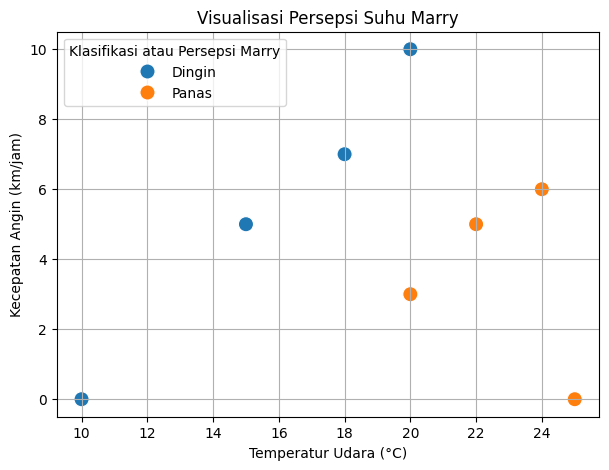

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Temperatur Udara (°C)",
    y="Kecepatan Angin (km/jam)",
    hue="Klasifikasi atau Persepsi Marry",
    s=120
)
plt.title("Visualisasi Persepsi Suhu Marry")
plt.xlabel("Temperatur Udara (°C)")
plt.ylabel("Kecepatan Angin (km/jam)")
plt.grid(True)
plt.show()

In [15]:
X = df[["Temperatur Udara (°C)", "Kecepatan Angin (km/jam)"]]
y = df["Klasifikasi atau Persepsi Marry"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [20]:
akurasi_k = {}

# k maksimal = jumlah data latih
max_k = len(X_train)

for k in range(1, max_k + 1):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    akurasi_k[k] = accuracy_score(y_test, pred)

print("\n=== Akurasi tiap nilai k ===")
print(akurasi_k)


=== Akurasi tiap nilai k ===
{1: 1.0, 2: 1.0, 3: 0.5, 4: 0.5, 5: 0.5, 6: 0.5}


In [21]:
# Pilih k terbaik
k_terbaik = max(akurasi_k, key=akurasi_k.get)
print("\nNilai k terbaik:", k_terbaik)


Nilai k terbaik: 1


In [22]:
#latih ulang model
knn = KNeighborsClassifier(n_neighbors=k_terbaik)
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=1)

In [23]:
# Prediksi data baru: suhu 16°C dan angin 3 km/jam
sample = pd.DataFrame({
    "Temperatur Udara (°C)": [16],
    "Kecepatan Angin (km/jam)": [3]
})

hasil_prediksi = knn.predict(sample)[0]

In [24]:
print("\n=== HASIL PREDIKSI ===")
print(f"Persepsi Marry saat suhu 16°C dan angin 3 km/jam adalah: {hasil_prediksi}")


=== HASIL PREDIKSI ===
Persepsi Marry saat suhu 16°C dan angin 3 km/jam adalah: Dingin
